In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

### Load Iris Dataset

First, we load the famous Iris dataset, which is a classic dataset for classification problems.

In [ ]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Display the first few rows of the data
display(X.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Train Decision Tree Classifier

Next, we train a simple Decision Tree Classifier on the entire dataset. For visualization purposes, we use the complete dataset.

In [ ]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X, y)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### Visualize the Decision Tree

Finally, we visualize the trained decision tree. This helps in understanding how the model makes decisions based on the input features.

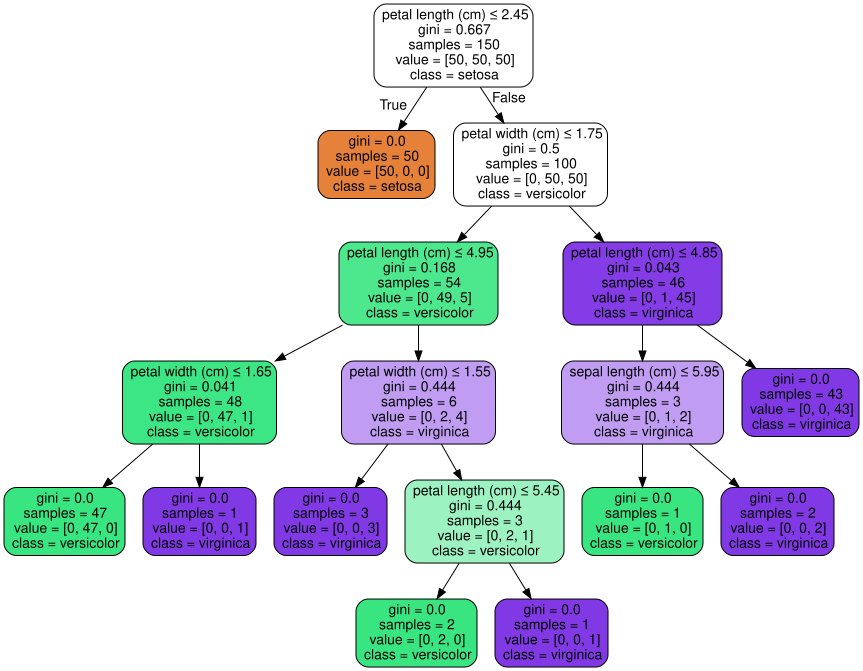

In [ ]:
dot_data = export_graphviz(
    dt_classifier,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)

display(graph)

### Explanation of the Decision Tree Output

The output above is a visual representation of the trained Decision Tree. Here's what it means:

*   **Nodes**: Each box (node) in the tree represents a decision point or a leaf node.
*   **Conditions**: The top line in a non-leaf node (e.g., `petal length (cm) <= 2.45`) is the condition the model uses to split the data.
*   **Gini Impurity**: `gini` measures the purity of the node. A Gini of `0.0` means all samples in that node belong to the same class.
*   **Samples**: `samples` indicates how many data points reached that node.
*   **Value**: `value` shows the distribution of classes at that node (e.g., `[50, 0, 0]` means 50 samples of the first class, 0 of the second, and 0 of the third).
*   **Class**: `class` indicates the predicted class for samples that fall into that leaf node.
*   **Colors**: The color intensity and hue of the nodes indicate the dominant class in that node and its purity (darker color means higher purity).

### Decision Boundary Visualization (2D Scatter Plot)

To visualize the decision boundaries, we'll select two features ('petal length (cm)' and 'petal width (cm)') to create a 2D scatter plot. A new Decision Tree will be trained on these two features to clearly show the separation regions.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


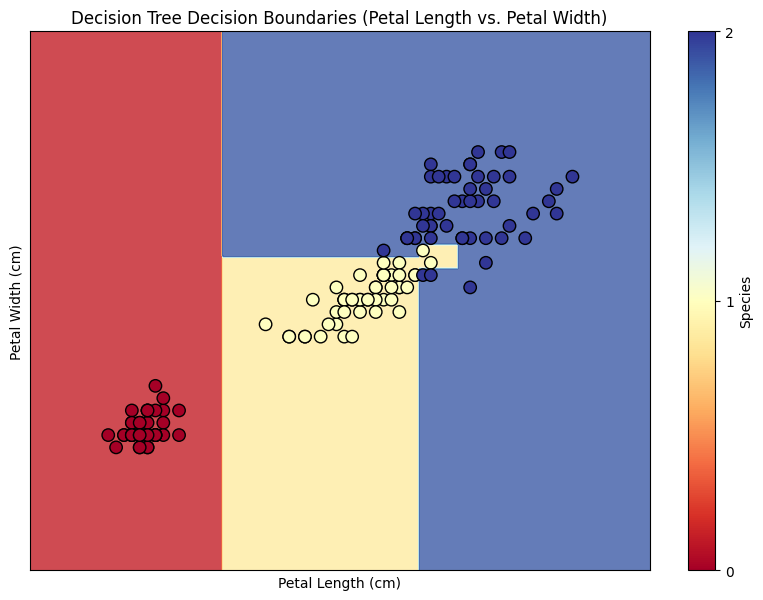

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select two features for 2D visualization
X_2d = X[['petal length (cm)', 'petal width (cm)']]
y_2d = y

# Train a new Decision Tree Classifier on the 2D data
dt_classifier_2d = DecisionTreeClassifier(random_state=42)
dt_classifier_2d.fit(X_2d, y_2d)

# Create a meshgrid to plot the decision boundaries
x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z = dt_classifier_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries and data points
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plot the training points
scatter = plt.scatter(X_2d.iloc[:, 0], X_2d.iloc[:, 1], c=y_2d,
                      cmap=plt.cm.RdYlBu, edgecolor='k', s=80)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Decision Tree Decision Boundaries (Petal Length vs. Petal Width)')
plt.colorbar(scatter, label='Species', ticks=[0, 1, 2])
plt.xticks(())
plt.yticks(())
plt.show()

### Explanation of the 2D Scatter Plot with Decision Boundaries

This scatter plot visualizes how the Decision Tree separates the different Iris species using only two features: 'Petal Length' and 'Petal Width'.

*   **Colored Background Regions**: These areas show the decision regions of the tree. Each color represents a predicted species class.
*   **Scatter Points**: Each dot is an individual Iris flower, colored according to its actual species.
*   **Straight Lines (Decision Boundaries)**: The straight lines are the 'cuts' or rules made by the decision tree to divide the feature space. Anything on one side of a line is classified one way, and anything on the other side is classified differently.